# Time of Emergence — Simple Cumulative t-test (all four HiLLA models)
## GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5

**Method:**  
For each pair of simulations (one HiLLA member, one matched SSP2-4.5 member), and for a given year Y,  
collect all annual-mean GMSAT values from 2035 (SAI start) up to and including year Y in each simulation.  
Apply a one-sided Student's t-test (`HiLLA < SSP2-4.5`, i.e. SAI has cooled) at p < 0.05.  
**ToE for a member pair** = first year Y at which the test is significant.  
**ToE for a model** = first year Y at which *all* available member pairs are simultaneously significant.

**Models and member counts:**
| Model | HiLLA members | SSP2-4.5 members |
|---|---|---|
| MIROC-ES2H | 10 (r01–r10) | 10 (r01–r10, same bucket) |
| CESM2-WACCM | 3 (r1–r3) | 3 (CMIP6 pangeo zarr) |
| UKESM1-1 | 3 (r12, r2, r3 i1p1f2) | 3 (r12, r2, r3 i1p1f1) |
| E3SMv3 | 3 (0101, 0151, 0201) | 3 (0101, 0151, 0201) |

In [1]:
import sys
import fsspec
import s3fs
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import netCDF4
from scipy import stats

matplotlib.rcParams.update({'font.size': 12})

sys.path.append('../shared/Code_examples/G6-1.5K_example/')
from Utils import weighted_annual_resample, spatial_mean, set_time_to_center_of_bounds

SAI_START = 2035   # first year of SAI — data from both runs used from this year onwards

## 1. File paths

In [2]:
# ── MIROC-ES2H ────────────────────────────────────────────────────────────────
_MIROC = 's3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Amon'
miroc_n = 10
miroc_HiLLA_files  = [f'{_MIROC}/tas_G6-1.5K-HiLLA_r{i:02d}.nc' for i in range(1, miroc_n + 1)]
miroc_ssp245_files = [f'{_MIROC}/tas_baseline_r{i:02d}.nc'       for i in range(1, miroc_n + 1)]

# ── CESM2-WACCM ───────────────────────────────────────────────────────────────
_CESM_HiLLA = 's3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA'
# r1 is split into two files; r2 and r3 are single files
cesm_HiLLA_files = [
    [f'{_CESM_HiLLA}/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TREFHT.203501-203912.nc',
     f'{_CESM_HiLLA}/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.TREFHT.204001-208412.nc'],
    [f'{_CESM_HiLLA}/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.TREFHT.203501-208412.nc'],
    [f'{_CESM_HiLLA}/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.TREFHT.203501-208412.nc'],
]
# SSP2-4.5 sourced from the public CMIP6 pangeo zarr catalogue
cesm_ssp245_zarr = None   # populated in cell below

# ── UKESM1-1 ─────────────────────────────────────────────────────────────────
_UKESM_HiLLA  = 's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA'
_UKESM_SSP245 = 's3://reflective-persistent-prod-large/UKESM1-1/SSP245'
ukesm_HiLLA_members  = ['r12i1p1f2', 'r2i1p1f2',  'r3i1p1f2']
ukesm_ssp245_members = ['r12i1p1f1', 'r2i1p1f1',  'r3i1p1f1']
# each member directory contains multiple time-split .nc files
ukesm_HiLLA_paths  = [f'{_UKESM_HiLLA}/{m}/apm/Amon/tas/'  for m in ukesm_HiLLA_members]
ukesm_ssp245_paths = [f'{_UKESM_SSP245}/{m}/ap5/Amon/tas/' for m in ukesm_ssp245_members]

# ── E3SMv3 ────────────────────────────────────────────────────────────────────
_E3SM = 's3://reflective-persistent-prod-large/E3SMv3/G6-1.5K-HiLLA'
_E3SM_MAP = f'{_E3SM}/maps/map_ne30pg2_to_cmip6_180x360_aave.20200201.nc'
e3sm_runs = ['0101', '0151', '0201']
e3sm_HiLLA_dirs  = [f'{_E3SM}/v3.LR.ssp245.g6_hilla.sai.{r}/Amon/TREFHT/gn/13112025/' for r in e3sm_runs]
e3sm_ssp245_dirs = [f'{_E3SM}/v3.LR.ssp245_{r}/Amon/TREFHT/gn/13112025/'               for r in e3sm_runs]

print('File paths defined.')

File paths defined.


## 2. Data loading

In [3]:
# ── Generic single-file reader ─────────────────────────────────────────────────
def open_nc(path, rename_var=None, set_time_bounds=False):
    """Open a single NetCDF from S3; optionally rename variable and fix time."""
    with fsspec.open(path, mode='rb') as f:
        ds = xr.open_dataset(f, engine='h5netcdf', chunks={}).load()
    if rename_var:
        ds = ds.rename({rename_var: 'tas'})
    if set_time_bounds:
        ds = set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds')
    return ds


# ── Multi-file path reader (UKESM) ─────────────────────────────────────────────
def open_mf_from_path(s3_dir, drop_year=None):
    """Open and concatenate all .nc files in an S3 directory path."""
    fs = s3fs.S3FileSystem(anon=False)
    files = sorted(fs.ls(s3_dir.replace('s3://', '')))
    file_objs = [fsspec.open(f's3://{f}', mode='rb').open() for f in files]
    ds = xr.open_mfdataset(file_objs, combine='nested', concat_dim='time', chunks={}).load()
    if drop_year is not None:
        ds = ds.sel(time=(ds.time.dt.year != drop_year))
    return ds


# ── Multi-file concat reader (CESM r1, E3SM) ───────────────────────────────────
def open_concat(path_list, rename_var=None, set_time_bounds=False):
    """Open and concatenate an ordered list of S3 file paths along time."""
    parts = [open_nc(p, rename_var=rename_var, set_time_bounds=set_time_bounds)
             for p in path_list]
    return xr.concat(parts, dim='time')


# ── E3SM multi-file reader ─────────────────────────────────────────────────────
def open_e3sm_dir(s3_dir):
    """Concatenate all time-split TREFHT files in an E3SM Amon directory."""
    fs = s3fs.S3FileSystem(anon=False)
    files = sorted(fs.ls(s3_dir.replace('s3://', '')))
    parts = []
    for f in files:
        with fs.open(f, 'rb') as fobj:
            data = fobj.read()
        nc = netCDF4.Dataset('dummy', memory=data)
        time_raw  = nc.variables['time'][:]
        trefht    = nc.variables['TREFHT'][:]
        # decode time manually (days since ...)
        t_units   = nc.variables['time'].units
        t_cal     = getattr(nc.variables['time'], 'calendar', 'standard')
        times     = netCDF4.num2date(time_raw, t_units, t_cal)
        years     = np.array([t.year for t in times])
        months    = np.array([t.month for t in times])
        parts.append((years, months, trefht))
    years_all  = np.concatenate([p[0] for p in parts])
    months_all = np.concatenate([p[1] for p in parts])
    trefht_all = np.concatenate([p[2] for p in parts], axis=0)  # (time, ncol)
    return years_all, months_all, trefht_all


print('Reader functions defined.')

Reader functions defined.


In [4]:
# ── Load E3SM area weights (from conservative regridding map) ──────────────────
fs_anon = s3fs.S3FileSystem(anon=False)
with fs_anon.open(_E3SM_MAP.replace('s3://', ''), 'rb') as f:
    map_data = f.read()
nc_map = netCDF4.Dataset('dummy', memory=map_data)
e3sm_area_weights = np.array(nc_map.variables['area_a'][:])
e3sm_area_weights = e3sm_area_weights / e3sm_area_weights.sum()  # normalise
print(f'E3SM area weights loaded: {e3sm_area_weights.shape}, sum = {e3sm_area_weights.sum():.4f}')

E3SM area weights loaded: (21600,), sum = 1.0000


In [5]:
# ── Load MIROC data ────────────────────────────────────────────────────────────
print('Loading MIROC-ES2H...')
miroc_HiLLA_ds  = [open_nc(f) for f in miroc_HiLLA_files]
miroc_ssp245_ds = [open_nc(f) for f in miroc_ssp245_files]
print(f'  HiLLA:  {len(miroc_HiLLA_ds)} members, '
      f'years {int(miroc_HiLLA_ds[0].time.dt.year.min())}–{int(miroc_HiLLA_ds[0].time.dt.year.max())}')
print(f'  SSP245: {len(miroc_ssp245_ds)} members, '
      f'years {int(miroc_ssp245_ds[0].time.dt.year.min())}–{int(miroc_ssp245_ds[0].time.dt.year.max())}')

Loading MIROC-ES2H...
  HiLLA:  10 members, years 2035–2084
  SSP245: 10 members, years 2020–2084


In [6]:
# ── Load CESM2-WACCM HiLLA ────────────────────────────────────────────────────
print('Loading CESM2-WACCM HiLLA...')
cesm_HiLLA_ds = []
for i, file_list in enumerate(cesm_HiLLA_files):
    if len(file_list) == 1:
        ds = open_nc(file_list[0], rename_var='TREFHT', set_time_bounds=True)
    else:
        ds = open_concat(file_list, rename_var='TREFHT', set_time_bounds=True)
    cesm_HiLLA_ds.append(ds)
    print(f'  r{i+1}: years {int(ds.time.dt.year.min())}–{int(ds.time.dt.year.max())}')

# ── Load CESM2-WACCM SSP245 from CMIP6 pangeo zarr catalogue ──────────────────
print('Loading CESM2-WACCM SSP245 from CMIP6 catalogue...')
cmip6_df = pd.read_csv('https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv')
cesm_subset = cmip6_df.query(
    "activity_id=='ScenarioMIP' & source_id=='CESM2-WACCM' "
    "& experiment_id=='ssp245' & table_id=='Amon' & variable_id=='tas'"
)
print(f'  Found {len(cesm_subset)} CESM2-WACCM SSP245 Amon tas members in catalogue')
cesm_ssp245_ds = []
for i in range(3):
    zstore = cesm_subset.zstore.values[i]
    member = cesm_subset.member_id.values[i]
    ds = xr.open_dataset(zstore, engine='zarr', consolidated=True,
                         chunks={}, storage_options={'anon': True})
    # restrict to SAI era and beyond to save memory
    ds = ds.sel(time=ds.time.dt.year >= SAI_START).load()
    cesm_ssp245_ds.append(ds)
    print(f'  {member}: years {int(ds.time.dt.year.min())}–{int(ds.time.dt.year.max())}')

Loading CESM2-WACCM HiLLA...
  r1: years 2035–2084
  r2: years 2035–2084
  r3: years 2035–2084
Loading CESM2-WACCM SSP245 from CMIP6 catalogue...
  Found 5 CESM2-WACCM SSP245 Amon tas members in catalogue
  r1i1p1f1: years 2035–2100
  r4i1p1f1: years 2035–2100
  r3i1p1f1: years 2035–2100


In [7]:
# ── Load UKESM1-1 ─────────────────────────────────────────────────────────────
print('Loading UKESM1-1 HiLLA...')
ukesm_HiLLA_ds = []
for m, path in zip(ukesm_HiLLA_members, ukesm_HiLLA_paths):
    ds = open_mf_from_path(path, drop_year=2084)  # UKESM missing Dec 2084
    ukesm_HiLLA_ds.append(ds)
    print(f'  {m}: years {int(ds.time.dt.year.min())}–{int(ds.time.dt.year.max())}')

print('Loading UKESM1-1 SSP245...')
ukesm_ssp245_ds = []
for m, path in zip(ukesm_ssp245_members, ukesm_ssp245_paths):
    ds = open_mf_from_path(path)
    # restrict to SAI era to save memory
    ds = ds.sel(time=ds.time.dt.year >= SAI_START)
    ukesm_ssp245_ds.append(ds)
    print(f'  {m}: years {int(ds.time.dt.year.min())}–{int(ds.time.dt.year.max())}')

Loading UKESM1-1 HiLLA...
  r12i1p1f2: years 2034–2083
  r2i1p1f2: years 2034–2083
  r3i1p1f2: years 2034–2083
Loading UKESM1-1 SSP245...
  r12i1p1f1: years 2035–2100
  r2i1p1f1: years 2035–2100
  r3i1p1f1: years 2035–2100


In [8]:
# ── Load E3SMv3 ───────────────────────────────────────────────────────────────
print('Loading E3SMv3...')

def e3sm_global_annual_means(dirs, area_w):
    """Read E3SM native-grid TREFHT, apply area weights, return dict of annual means.
    Returns list of (years_arr, gmsat_arr) tuples, one per member.
    """
    result = []
    for d in dirs:
        years_m, months_m, trefht_m = open_e3sm_dir(d)
        # area-weighted global mean for each month
        gmsat_monthly = (trefht_m * area_w[np.newaxis, :]).sum(axis=1)
        # annual means (simple average of 12 months per year)
        unique_years = np.unique(years_m)
        gmsat_annual = np.array([
            gmsat_monthly[years_m == y].mean() for y in unique_years
        ])
        result.append((unique_years, gmsat_annual))
    return result

e3sm_HiLLA_ts  = e3sm_global_annual_means(e3sm_HiLLA_dirs,  e3sm_area_weights)
e3sm_ssp245_ts = e3sm_global_annual_means(e3sm_ssp245_dirs, e3sm_area_weights)

for i, (run, (yrs, _)) in enumerate(zip(e3sm_runs, e3sm_HiLLA_ts)):
    print(f'  HiLLA  {run}: years {yrs[0]}–{yrs[-1]}')
for i, (run, (yrs, _)) in enumerate(zip(e3sm_runs, e3sm_ssp245_ts)):
    print(f'  SSP245 {run}: years {yrs[0]}–{yrs[-1]}')

Loading E3SMv3...
  HiLLA  0101: years 2035–2085
  HiLLA  0151: years 2035–2085
  HiLLA  0201: years 2035–2085
  SSP245 0101: years 2015–2085
  SSP245 0151: years 2015–2085
  SSP245 0201: years 2015–2085


## 3. Global annual mean temperature timeseries
For MIROC, CESM, and UKESM the data is on regular lat/lon grids; use cosine-latitude area weighting.

In [9]:
def global_annual_mean(ds, var='tas', lat_name='lat', lon_name='lon',
                       sort_lat=False):
    """Area-weighted global annual mean timeseries from a monthly dataset.
    Returns a DataArray indexed by year (integer).
    """
    da = ds[var]
    if sort_lat:
        da = da.sortby(lat_name)
    weights = np.cos(np.deg2rad(da[lat_name]))
    weights /= weights.sum()
    # weighted mean over lat, then simple mean over lon
    gmean = (da * weights).sum(lat_name).mean(lon_name)
    # annual mean weighted by month length
    gmean_annual = weighted_annual_resample(gmean.to_dataset(name=var), var=var)[var]
    # return indexed by integer year
    return gmean_annual.assign_coords(time=gmean_annual.time.dt.year.values)


# ── MIROC (descending lat → sort) ─────────────────────────────────────────────
print('Computing MIROC global means...')
miroc_HiLLA_gmsat  = [global_annual_mean(ds, sort_lat=True) for ds in miroc_HiLLA_ds]
miroc_ssp245_gmsat = [global_annual_mean(ds, sort_lat=True) for ds in miroc_ssp245_ds]

# ── CESM2-WACCM ───────────────────────────────────────────────────────────────
print('Computing CESM2 global means...')
cesm_HiLLA_gmsat  = [global_annual_mean(ds, var='tas', lat_name='lat', lon_name='lon')
                     for ds in cesm_HiLLA_ds]
cesm_ssp245_gmsat = [global_annual_mean(ds, var='tas', lat_name='lat', lon_name='lon')
                     for ds in cesm_ssp245_ds]

# ── UKESM1-1 ─────────────────────────────────────────────────────────────────
print('Computing UKESM global means...')
ukesm_HiLLA_gmsat  = [global_annual_mean(ds, lat_name='lat', lon_name='lon')
                      for ds in ukesm_HiLLA_ds]
ukesm_ssp245_gmsat = [global_annual_mean(ds, lat_name='lat', lon_name='lon')
                      for ds in ukesm_ssp245_ds]

print('Done.')

Computing MIROC global means...
Computing CESM2 global means...
Computing UKESM global means...
Done.


## 4. Time of Emergence

In [41]:
pthresh = 0.05

In [42]:
def cumulative_ttest_toe(hilla_ts, ssp245_ts, start_year=SAI_START,
                         alpha=pthresh, min_n=5):
    """Cumulative one-sided t-test ToE for a single member pair.

    For year Y in [start_year, end], collect all annual values in
    [start_year, Y] from both simulations and test HiLLA < SSP2-4.5.
    ToE = first Y where p < alpha (and at least min_n data points).

    Parameters
    ----------
    hilla_ts, ssp245_ts : array-like of (years_arr, values_arr) tuples
                          OR xarray DataArrays indexed by integer year.
    Returns (toe_year or None, p_values_dict).
    """
    # unpack to numpy arrays indexed by year
    if isinstance(hilla_ts, tuple):
        h_yrs, h_vals = hilla_ts
        s_yrs, s_vals = ssp245_ts
    else:
        h_yrs  = hilla_ts.time.values.astype(int)
        h_vals = hilla_ts.values
        s_yrs  = ssp245_ts.time.values.astype(int)
        s_vals = ssp245_ts.values

    # common years from SAI start onward
    h_mask = h_yrs >= start_year
    s_mask = s_yrs >= start_year
    h_yrs, h_vals = h_yrs[h_mask], h_vals[h_mask]
    s_yrs, s_vals = s_yrs[s_mask], s_vals[s_mask]
    end_year = min(h_yrs.max(), s_yrs.max())

    p_vals = {}
    toe = None
    for Y in range(start_year, int(end_year) + 1):
        h_window = h_vals[h_yrs <= Y]
        s_window = s_vals[s_yrs <= Y]
        n = min(len(h_window), len(s_window))
        if n < min_n:
            p_vals[Y] = np.nan
            continue
        _, p = stats.ttest_ind(h_window, s_window,
                               equal_var=False, alternative='less')
        p_vals[Y] = p
        if toe is None and p < alpha:
            toe = Y
    return toe, p_vals


def model_toe(hilla_list, ssp245_list, **kwargs):
    """Compute per-member ToE and model-level ToE (all members significant).

    Returns:
        member_toes : list of per-member ToE (int or None)
        model_toe   : first year all members are simultaneously significant
        all_pvals   : list of p-value dicts, one per member
    """
    member_toes = []
    all_pvals   = []
    for h, s in zip(hilla_list, ssp245_list):
        toe, pvs = cumulative_ttest_toe(h, s, **kwargs)
        member_toes.append(toe)
        all_pvals.append(pvs)

    # model ToE: first year all members have p < alpha
    # build a combined year range
    all_years = sorted(set().union(*[set(pv.keys()) for pv in all_pvals]))
    alpha = kwargs.get('alpha', pthresh)
    m_toe = None
    for Y in all_years:
        if all(pv.get(Y, np.nan) < alpha for pv in all_pvals):
            m_toe = Y
            break

    return member_toes, m_toe, all_pvals


print('ToE functions defined.')

ToE functions defined.


In [43]:
# ── Apply to all models ────────────────────────────────────────────────────────

print('MIROC-ES2H')
miroc_mem_toes, miroc_model_toe, miroc_pvals = model_toe(
    miroc_HiLLA_gmsat, miroc_ssp245_gmsat)
print(f'  Member ToEs: {miroc_mem_toes}')
print(f'  Model ToE:   {miroc_model_toe}')

print('\nCESM2-WACCM')
cesm_mem_toes, cesm_model_toe, cesm_pvals = model_toe(
    cesm_HiLLA_gmsat, cesm_ssp245_gmsat)
print(f'  Member ToEs: {cesm_mem_toes}')
print(f'  Model ToE:   {cesm_model_toe}')

print('\nUKESM1-1')
ukesm_mem_toes, ukesm_model_toe, ukesm_pvals = model_toe(
    ukesm_HiLLA_gmsat, ukesm_ssp245_gmsat)
print(f'  Member ToEs: {ukesm_mem_toes}')
print(f'  Model ToE:   {ukesm_model_toe}')

print('\nE3SMv3')
e3sm_mem_toes, e3sm_model_toe, e3sm_pvals = model_toe(
    e3sm_HiLLA_ts, e3sm_ssp245_ts)
print(f'  Member ToEs: {e3sm_mem_toes}')
print(f'  Model ToE:   {e3sm_model_toe}')

MIROC-ES2H
  Member ToEs: [2041, 2039, 2039, 2042, 2039, 2039, 2039, 2041, 2039, 2040]
  Model ToE:   2042

CESM2-WACCM
  Member ToEs: [2043, 2045, 2039]
  Model ToE:   2045

UKESM1-1
  Member ToEs: [2040, 2040, 2040]
  Model ToE:   2040

E3SMv3
  Member ToEs: [2045, 2047, 2041]
  Model ToE:   2047


## 5. Visualisation
### 5a. p-value evolution and ToE per model

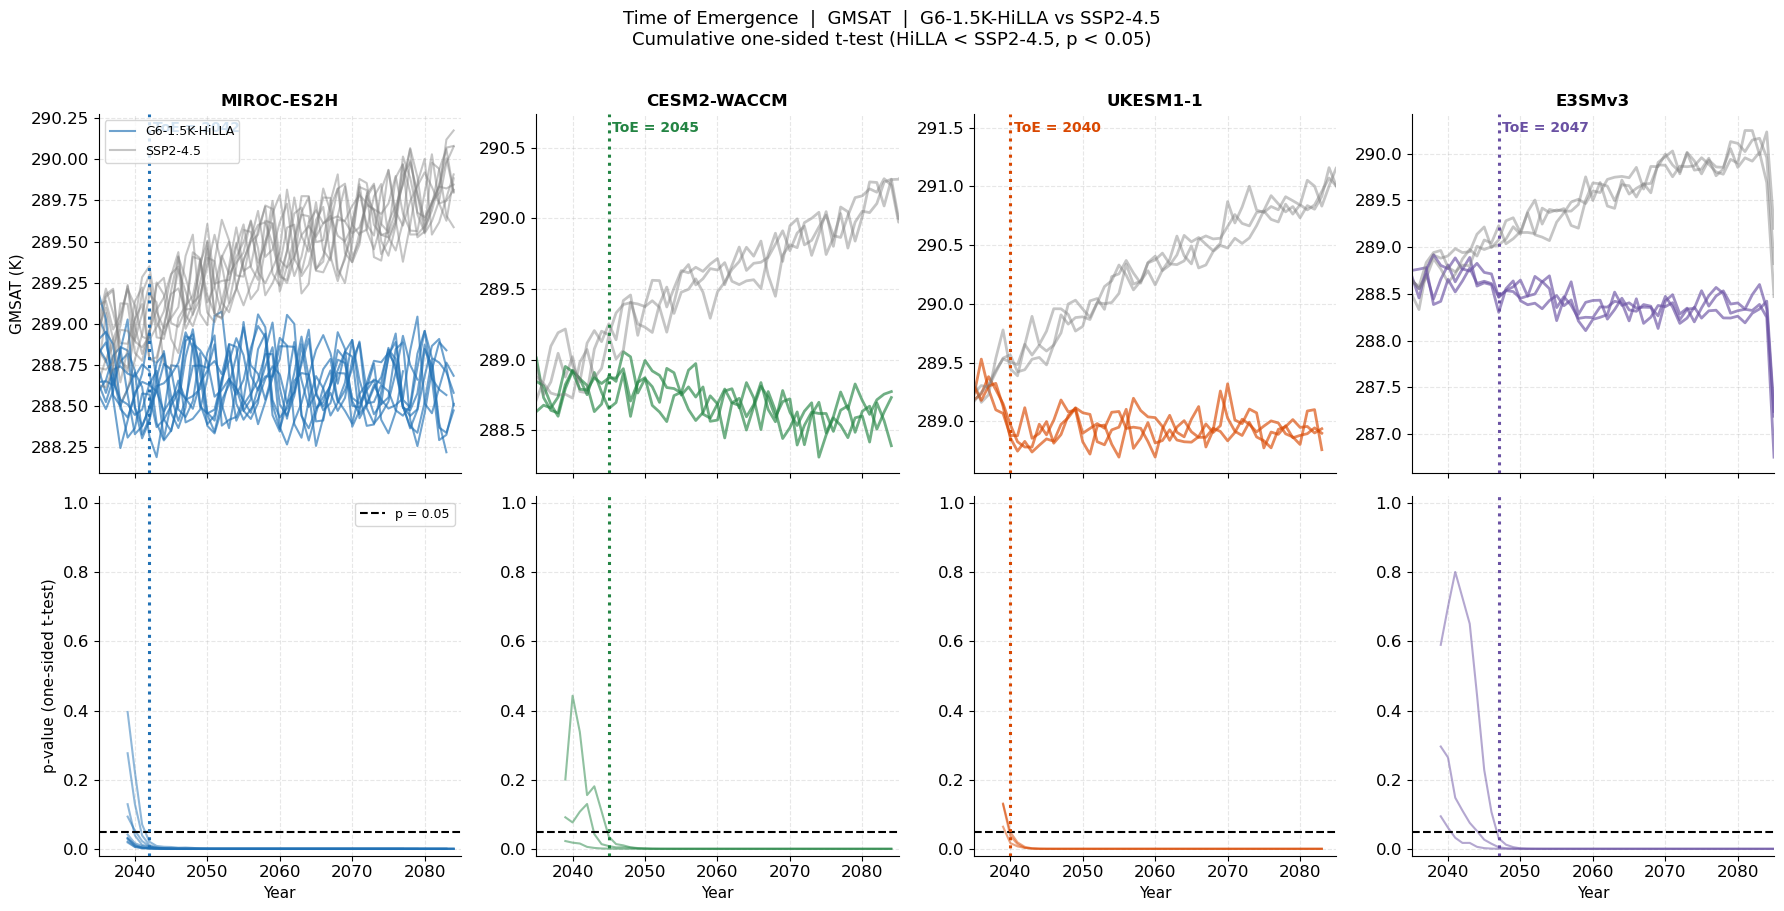

In [24]:
MODEL_CONFIGS = [
    ('MIROC-ES2H',   miroc_pvals,  miroc_mem_toes,  miroc_model_toe,
     miroc_HiLLA_gmsat,  miroc_ssp245_gmsat,  '#2171B5'),
    ('CESM2-WACCM',  cesm_pvals,   cesm_mem_toes,   cesm_model_toe,
     cesm_HiLLA_gmsat,   cesm_ssp245_gmsat,   '#238443'),
    ('UKESM1-1',     ukesm_pvals,  ukesm_mem_toes,  ukesm_model_toe,
     ukesm_HiLLA_gmsat,  ukesm_ssp245_gmsat,  '#D94801'),
    ('E3SMv3',       e3sm_pvals,   e3sm_mem_toes,   e3sm_model_toe,
     e3sm_HiLLA_ts,      e3sm_ssp245_ts,      '#6A51A3'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex='col')
fig.subplots_adjust(hspace=0.08, wspace=0.3)

for col, (model, pvals, mem_toes, m_toe, hilla_list, ssp_list, col_c) in enumerate(MODEL_CONFIGS):
    ax_ts = axes[0, col]
    ax_pv = axes[1, col]
    light  = col_c + '55'  # transparent version

    # ── top row: GMSAT timeseries ──────────────────────────────────────────────
    for i, (h, s) in enumerate(zip(hilla_list, ssp_list)):
        if isinstance(h, tuple):
            h_yrs, h_vals = h
            s_yrs, s_vals = s
        else:
            h_yrs  = h.time.values.astype(int)
            h_vals = h.values
            s_yrs  = s.time.values.astype(int)
            s_vals = s.values
        mask_h = h_yrs >= SAI_START
        mask_s = s_yrs >= SAI_START
        lw = 1.5 if len(hilla_list) > 5 else 2.0
        ax_ts.plot(h_yrs[mask_h], h_vals[mask_h], color=col_c, lw=lw, alpha=0.65,
                   label='G6-1.5K-HiLLA' if i == 0 else '_')
        ax_ts.plot(s_yrs[mask_s], s_vals[mask_s], color='gray',  lw=lw, alpha=0.45,
                   label='SSP2-4.5' if i == 0 else '_')

    if m_toe:
        ax_ts.axvline(m_toe, color=col_c, lw=2.2, ls=':', zorder=5)
        ax_ts.text(m_toe + 0.5, 0.98,  f'ToE = {m_toe}',
                   transform=ax_ts.get_xaxis_transform(),
                   color=col_c, fontsize=10, va='top', fontweight='bold')
    ax_ts.set_title(model, fontsize=12, fontweight='bold', pad=6)
    if col == 0:
        ax_ts.set_ylabel('GMSAT (K)', fontsize=11)
        ax_ts.legend(fontsize=9, loc='upper left', framealpha=0.8)
    ax_ts.grid(ls='--', alpha=0.3)
    for sp in ('top', 'right'):
        ax_ts.spines[sp].set_visible(False)

    # ── bottom row: p-value evolution ─────────────────────────────────────────
    for i, pv in enumerate(pvals):
        years_pv = np.array(sorted(pv.keys()))
        p_arr    = np.array([pv[y] for y in years_pv])
        ax_pv.plot(years_pv, p_arr, color=col_c, lw=1.5, alpha=0.5,
                   label=f'member {i+1}' if len(pvals) <= 3 else None)

    ax_pv.axhline(0.05, color='k', lw=1.5, ls='--', label='p = 0.05')
    if m_toe:
        ax_pv.axvline(m_toe, color=col_c, lw=2.2, ls=':', zorder=5)
    ax_pv.set_ylim(-0.02, 1.02)
    ax_pv.set_xlim(SAI_START, 2085)
    ax_pv.set_xlabel('Year', fontsize=11)
    if col == 0:
        ax_pv.set_ylabel('p-value (one-sided t-test)', fontsize=11)
        ax_pv.legend(fontsize=9, framealpha=0.8)
    ax_pv.grid(ls='--', alpha=0.3)
    for sp in ('top', 'right'):
        ax_pv.spines[sp].set_visible(False)

fig.suptitle(
    'Time of Emergence  |  GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5\n'
    'Cumulative one-sided t-test (HiLLA < SSP2-4.5, p < 0.05)',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('Figures/ToE_GMSAT_v6_pvals.png', dpi=200, bbox_inches='tight')
plt.show()

### 5b. Summary: member-level ToE spread and model-level ToE

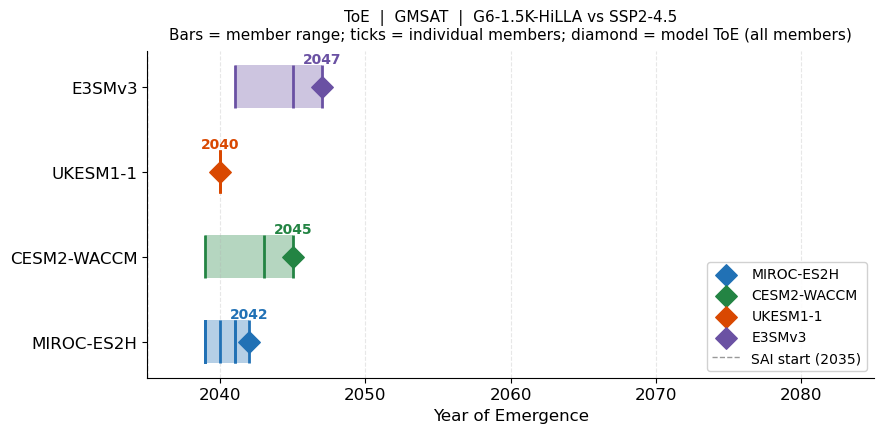

In [15]:
fig2, ax = plt.subplots(figsize=(9, 4.5))

models_plot = [
    ('MIROC-ES2H',  miroc_mem_toes,  miroc_model_toe,  '#2171B5'),
    ('CESM2-WACCM', cesm_mem_toes,   cesm_model_toe,   '#238443'),
    ('UKESM1-1',    ukesm_mem_toes,  ukesm_model_toe,  '#D94801'),
    ('E3SMv3',      e3sm_mem_toes,   e3sm_model_toe,   '#6A51A3'),
]

for y_pos, (model, mem_toes, m_toe, col_c) in enumerate(models_plot):
    valid = [t for t in mem_toes if t is not None]
    if valid:
        lo, hi = min(valid), max(valid)
        light = col_c + '55'
        if hi > lo:
            ax.barh(y_pos, hi - lo, left=lo, height=0.5,
                    color=light, zorder=1, linewidth=0)
        ax.vlines(valid, y_pos - 0.25, y_pos + 0.25,
                  color=col_c, lw=2, zorder=2)
    if m_toe is not None:
        ax.scatter([m_toe], [y_pos], color=col_c, s=120,
                   zorder=4, marker='D', label=model)
        ax.annotate(f'{m_toe}', (m_toe, y_pos + 0.28),
                    ha='center', fontsize=10, color=col_c, fontweight='bold')
    else:
        ax.scatter([], [], color=col_c, s=120, marker='D', label=model)

ax.set_xlim(SAI_START, 2085)
ax.set_yticks(range(len(models_plot)))
ax.set_yticklabels([m[0] for m in models_plot], fontsize=12)
ax.set_xlabel('Year of Emergence', fontsize=12)
ax.set_title(
    'ToE  |  GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5\n'
    'Bars = member range; ticks = individual members; diamond = model ToE (all members)',
    fontsize=11, pad=8
)
ax.axvline(SAI_START, color='k', lw=1, ls='--', alpha=0.4, label='SAI start (2035)')
ax.legend(fontsize=10, loc='lower right', framealpha=0.9)
ax.grid(axis='x', ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('Figures/ToE_GMSAT_v6_summary.png', dpi=200, bbox_inches='tight')
plt.show()

In [14]:
# ── Print summary table ────────────────────────────────────────────────────────
print(f'{'Model':<15} {'N members':>10} {'Member ToEs':>35} {'Model ToE':>10}')
print('-' * 75)
for model, mem_toes, m_toe, _ in models_plot:
    n = len(mem_toes)
    toes_str = str(mem_toes)
    print(f'{model:<15} {n:>10} {toes_str:>35} {str(m_toe):>10}')

Model            N members                         Member ToEs  Model ToE
---------------------------------------------------------------------------
MIROC-ES2H              10 [2041, 2039, 2039, 2042, 2039, 2039, 2039, 2041, 2039, 2040]       2042
CESM2-WACCM              3                  [2043, 2045, 2039]       2045
UKESM1-1                 3                  [2040, 2040, 2040]       2040
E3SMv3                   3                  [2045, 2047, 2041]       2047


## 6. Method 2 — Multi-start cumulative t-test  (min ToE approach)

For each possible start year s ∈ {2035, 2036, …, end − min\_n}, apply the same cumulative
one-sided t-test over the window [s, Y] for all Y ≥ s + min\_n − 1.
This produces a **ToE(s)** for every start year.

**Member ToE = min(ToE(s))** — the earliest year at which *any* window becomes significant.  
Windows starting after the early near-zero-signal period are not diluted by it, so they
detect emergence sooner. Taking the minimum directly addresses the conservative bias of Method 1.

**Model ToE** = year by which all member pairs have reached their min ToE, i.e. max over members of min(ToE(s)).

In [47]:
def multistart_ttest_toe(hilla_ts, ssp245_ts, start_year=SAI_START,
                         alpha=pthresh, min_n=5):
    """Multi-start cumulative t-test for a single member pair.

    For each start year s in [start_year, end - min_n], compute the cumulative
    one-sided Welch t-test over window [s, Y] for all Y >= s + min_n - 1.
    Member ToE = min(ToE(s)) over all s.

    Returns
    -------
    member_toe   : int or None
    toe_by_start : dict {s: ToE(s) or None}
    pvals_by_start : dict {s: {Y: p}} — full p-value series per start year
    """
    # unpack to numpy arrays
    if isinstance(hilla_ts, tuple):
        h_yrs, h_vals = hilla_ts
        s_yrs, s_vals = ssp245_ts
    else:
        h_yrs  = hilla_ts.time.values.astype(int);  h_vals = hilla_ts.values
        s_yrs  = ssp245_ts.time.values.astype(int); s_vals = ssp245_ts.values

    # restrict both to SAI era
    h_mask = h_yrs >= start_year;  s_mask = s_yrs >= start_year
    h_yrs, h_vals = h_yrs[h_mask], h_vals[h_mask]
    s_yrs, s_vals = s_yrs[s_mask], s_vals[s_mask]
    end_year = int(min(h_yrs.max(), s_yrs.max()))

    toe_by_start   = {}
    pvals_by_start = {}

    for s in range(start_year, end_year - min_n + 2):
        h_from_s = h_vals[h_yrs >= s]
        s_from_s = s_vals[s_yrs >= s]
        y_range  = range(s + min_n - 1, end_year + 1)

        pvs = {}
        toe_s = None
        for Y in y_range:
            h_win = h_from_s[h_yrs[h_yrs >= s] <= Y]
            s_win = s_from_s[s_yrs[s_yrs >= s] <= Y]
            _, p  = stats.ttest_ind(h_win, s_win, equal_var=False, alternative='less')
            pvs[Y] = p
            if toe_s is None and p < alpha:
                toe_s = Y

        toe_by_start[s]   = toe_s
        pvals_by_start[s] = pvs

    valid_toes = [t for t in toe_by_start.values() if t is not None]
    member_toe = int(min(valid_toes)) if valid_toes else None

    return member_toe, toe_by_start, pvals_by_start


def model_multistart_toe(hilla_list, ssp245_list, **kwargs):
    """Apply multi-start ToE to all member pairs.

    Returns
    -------
    member_toes    : list of per-member min(ToE(s))
    model_toe      : max over members (last member to reach its min ToE)
    toe_by_start_all   : list of toe_by_start dicts, one per member
    pvals_by_start_all : list of pvals_by_start dicts, one per member
    """
    member_toes        = []
    toe_by_start_all   = []
    pvals_by_start_all = []

    for h, s in zip(hilla_list, ssp245_list):
        mt, tbs, pbs = multistart_ttest_toe(h, s, **kwargs)
        member_toes.append(mt)
        toe_by_start_all.append(tbs)
        pvals_by_start_all.append(pbs)

    valid = [t for t in member_toes if t is not None]
    m_toe = int(max(valid)) if valid else None

    return member_toes, m_toe, toe_by_start_all, pvals_by_start_all


# ── Apply to all models ────────────────────────────────────────────────────────
print('MIROC-ES2H')
miroc_mem_toes_ms, miroc_model_toe_ms, miroc_tbs_ms, miroc_pbs_ms = model_multistart_toe(
    miroc_HiLLA_gmsat, miroc_ssp245_gmsat)
print(f'  Member ToEs: {miroc_mem_toes_ms}')
print(f'  Model ToE:   {miroc_model_toe_ms}')

print('\nCESM2-WACCM')
cesm_mem_toes_ms, cesm_model_toe_ms, cesm_tbs_ms, cesm_pbs_ms = model_multistart_toe(
    cesm_HiLLA_gmsat, cesm_ssp245_gmsat)
print(f'  Member ToEs: {cesm_mem_toes_ms}')
print(f'  Model ToE:   {cesm_model_toe_ms}')

print('\nUKESM1-1')
ukesm_mem_toes_ms, ukesm_model_toe_ms, ukesm_tbs_ms, ukesm_pbs_ms = model_multistart_toe(
    ukesm_HiLLA_gmsat, ukesm_ssp245_gmsat)
print(f'  Member ToEs: {ukesm_mem_toes_ms}')
print(f'  Model ToE:   {ukesm_model_toe_ms}')

print('\nE3SMv3')
e3sm_mem_toes_ms, e3sm_model_toe_ms, e3sm_tbs_ms, e3sm_pbs_ms = model_multistart_toe(
    e3sm_HiLLA_ts, e3sm_ssp245_ts)
print(f'  Member ToEs: {e3sm_mem_toes_ms}')
print(f'  Model ToE:   {e3sm_model_toe_ms}')

MIROC-ES2H
  Member ToEs: [2040, 2039, 2039, 2042, 2039, 2039, 2039, 2041, 2039, 2040]
  Model ToE:   2042

CESM2-WACCM
  Member ToEs: [2040, 2045, 2039]
  Model ToE:   2045

UKESM1-1
  Member ToEs: [2040, 2040, 2040]
  Model ToE:   2040

E3SMv3
  Member ToEs: [2041, 2046, 2040]
  Model ToE:   2046


### 6a. p-value envelopes across start dates, per model

The shaded band shows the range of p-values across all start years at each Y.
The lower edge (minimum p) is the signal from the least-diluted window;
the upper edge (maximum p) is the most conservative window (always starting from 2035).
The model ToE is marked where the first member's minimum-p window crosses p = 0.05.

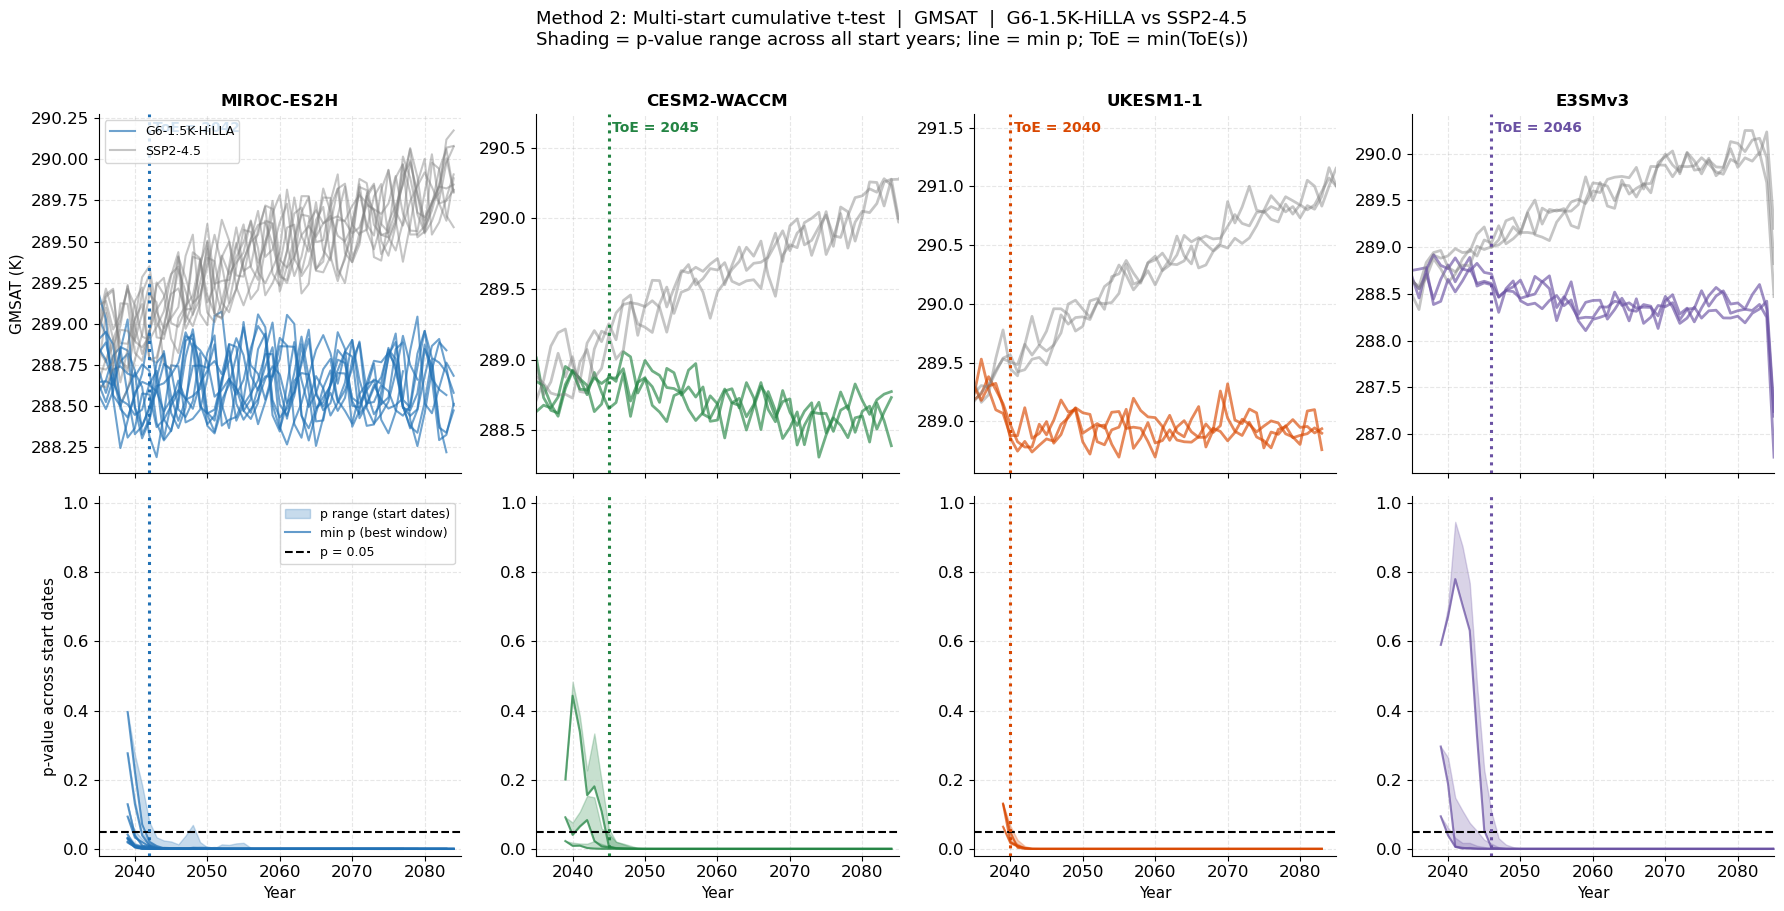

In [48]:
MODEL_CONFIGS_MS = [
    ('MIROC-ES2H',  miroc_pbs_ms,  miroc_mem_toes_ms,  miroc_model_toe_ms,
     miroc_HiLLA_gmsat,  miroc_ssp245_gmsat,  '#2171B5'),
    ('CESM2-WACCM', cesm_pbs_ms,   cesm_mem_toes_ms,   cesm_model_toe_ms,
     cesm_HiLLA_gmsat,   cesm_ssp245_gmsat,   '#238443'),
    ('UKESM1-1',    ukesm_pbs_ms,  ukesm_mem_toes_ms,  ukesm_model_toe_ms,
     ukesm_HiLLA_gmsat,  ukesm_ssp245_gmsat,  '#D94801'),
    ('E3SMv3',      e3sm_pbs_ms,   e3sm_mem_toes_ms,   e3sm_model_toe_ms,
     e3sm_HiLLA_ts,      e3sm_ssp245_ts,      '#6A51A3'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex='col')
fig.subplots_adjust(hspace=0.08, wspace=0.3)

for col, (model, pbs_all, mem_toes, m_toe, hilla_list, ssp_list, col_c) in enumerate(MODEL_CONFIGS_MS):
    ax_ts = axes[0, col]
    ax_pv = axes[1, col]
    light = col_c + '40'

    # ── top: GMSAT timeseries ──────────────────────────────────────────────────
    for i, (h, s) in enumerate(zip(hilla_list, ssp_list)):
        if isinstance(h, tuple):
            h_yrs, h_vals = h;  s_yrs, s_vals = s
        else:
            h_yrs = h.time.values.astype(int);  h_vals = h.values
            s_yrs = s.time.values.astype(int);  s_vals = s.values
        mask_h = h_yrs >= SAI_START;  mask_s = s_yrs >= SAI_START
        lw = 1.5 if len(hilla_list) > 5 else 2.0
        ax_ts.plot(h_yrs[mask_h], h_vals[mask_h], color=col_c, lw=lw, alpha=0.65,
                   label='G6-1.5K-HiLLA' if i == 0 else '_')
        ax_ts.plot(s_yrs[mask_s], s_vals[mask_s], color='gray', lw=lw, alpha=0.45,
                   label='SSP2-4.5' if i == 0 else '_')

    if m_toe:
        ax_ts.axvline(m_toe, color=col_c, lw=2.2, ls=':', zorder=5)
        ax_ts.text(m_toe + 0.5, 0.98, f'ToE = {m_toe}',
                   transform=ax_ts.get_xaxis_transform(),
                   color=col_c, fontsize=10, va='top', fontweight='bold')
    ax_ts.set_title(model, fontsize=12, fontweight='bold', pad=6)
    if col == 0:
        ax_ts.set_ylabel('GMSAT (K)', fontsize=11)
        ax_ts.legend(fontsize=9, loc='upper left', framealpha=0.8)
    ax_ts.grid(ls='--', alpha=0.3)
    for sp in ('top', 'right'):
        ax_ts.spines[sp].set_visible(False)

    # ── bottom: p-value envelope across start years ────────────────────────────
    for i, pbs in enumerate(pbs_all):
        # collect all years covered by any start-year window
        all_Y = sorted(set().union(*[set(pvs.keys()) for pvs in pbs.values()]))
        all_Y = np.array(all_Y)

        # for each Y, gather p-values from all start years that cover Y
        p_min = np.full(len(all_Y), np.nan)
        p_max = np.full(len(all_Y), np.nan)
        for j, Y in enumerate(all_Y):
            p_at_Y = [pvs[Y] for pvs in pbs.values() if Y in pvs]
            if p_at_Y:
                p_min[j] = np.nanmin(p_at_Y)
                p_max[j] = np.nanmax(p_at_Y)

        valid = ~np.isnan(p_min)
        ax_pv.fill_between(all_Y[valid], p_min[valid], p_max[valid],
                           color=light, zorder=1,
                           label='p range (start dates)' if i == 0 else '_')
        ax_pv.plot(all_Y[valid], p_min[valid], color=col_c, lw=1.5, alpha=0.7,
                   label='min p (best window)' if i == 0 else '_')

    ax_pv.axhline(pthresh, color='k', lw=1.5, ls='--', label=f'p = {pthresh}')
    if m_toe:
        ax_pv.axvline(m_toe, color=col_c, lw=2.2, ls=':', zorder=5)
    ax_pv.set_ylim(-0.02, 1.02)
    ax_pv.set_xlim(SAI_START, 2085)
    ax_pv.set_xlabel('Year', fontsize=11)
    if col == 0:
        ax_pv.set_ylabel('p-value across start dates', fontsize=11)
        ax_pv.legend(fontsize=9, framealpha=0.8)
    ax_pv.grid(ls='--', alpha=0.3)
    for sp in ('top', 'right'):
        ax_pv.spines[sp].set_visible(False)

fig.suptitle(
    'Method 2: Multi-start cumulative t-test  |  GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5\n'
    'Shading = p-value range across all start years; line = min p; ToE = min(ToE(s))',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('Figures/ToE_GMSAT_v6_multistart_pvals.png', dpi=200, bbox_inches='tight')
plt.show()

### 6b. Summary: Method 1 vs Method 2 comparison

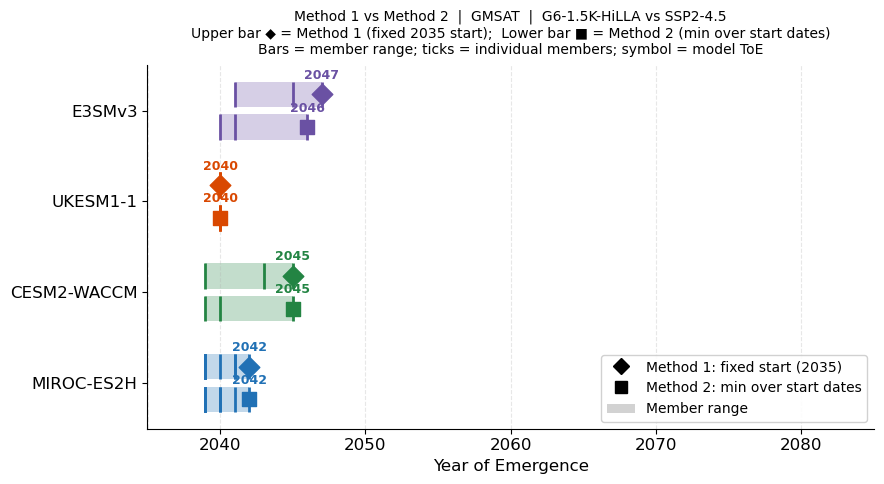

Model             M1 model ToE   M2 model ToE  Difference (yr)
--------------------------------------------------------------
MIROC-ES2H                2042           2042               +0
CESM2-WACCM               2045           2045               +0
UKESM1-1                  2040           2040               +0
E3SMv3                    2047           2046               -1


In [49]:
fig3, ax = plt.subplots(figsize=(9, 5))

models_compare = [
    ('MIROC-ES2H',  miroc_mem_toes,  miroc_model_toe,  miroc_mem_toes_ms,  miroc_model_toe_ms,  '#2171B5'),
    ('CESM2-WACCM', cesm_mem_toes,   cesm_model_toe,   cesm_mem_toes_ms,   cesm_model_toe_ms,   '#238443'),
    ('UKESM1-1',    ukesm_mem_toes,  ukesm_model_toe,  ukesm_mem_toes_ms,  ukesm_model_toe_ms,  '#D94801'),
    ('E3SMv3',      e3sm_mem_toes,   e3sm_model_toe,   e3sm_mem_toes_ms,   e3sm_model_toe_ms,   '#6A51A3'),
]

BAR_H = 0.28

for row, (model, m1_mem, m1_toe, m2_mem, m2_toe, col_c) in enumerate(models_compare):
    y1 = row + 0.18   # Method 1 (upper)
    y2 = row - 0.18   # Method 2 (lower)
    light = col_c + '45'

    for y_pos, mem_toes, m_toe, marker in [(y1, m1_mem, m1_toe, 'D'), (y2, m2_mem, m2_toe, 's')]:
        valid = [t for t in mem_toes if t is not None]
        if valid:
            lo, hi = min(valid), max(valid)
            if hi > lo:
                ax.barh(y_pos, hi - lo, left=lo, height=BAR_H,
                        color=light, zorder=1, linewidth=0)
            ax.vlines(valid, y_pos - BAR_H / 2, y_pos + BAR_H / 2,
                      color=col_c, lw=2, zorder=2)
        if m_toe is not None:
            ax.scatter([m_toe], [y_pos], color=col_c, s=110, zorder=4, marker=marker)
            ax.annotate(f'{m_toe}', (m_toe, y_pos + BAR_H / 2 + 0.03),
                        ha='center', fontsize=9, color=col_c, fontweight='bold')

ax.set_xlim(SAI_START, 2085)
ax.set_yticks(range(len(models_compare)))
ax.set_yticklabels([m[0] for m in models_compare], fontsize=12)
ax.set_xlabel('Year of Emergence', fontsize=12)
ax.set_title(
    'Method 1 vs Method 2  |  GMSAT  |  G6-1.5K-HiLLA vs SSP2-4.5\n'
    'Upper bar ◆ = Method 1 (fixed 2035 start);  Lower bar ■ = Method 2 (min over start dates)\n'
    'Bars = member range; ticks = individual members; symbol = model ToE',
    fontsize=10, pad=8
)
ax.axvline(SAI_START, color='k', lw=1, ls='--', alpha=0.4, label='SAI start (2035)')

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0], [0], color='k', lw=0, marker='D', markersize=8,
           label='Method 1: fixed start (2035)'),
    Line2D([0], [0], color='k', lw=0, marker='s', markersize=8,
           label='Method 2: min over start dates'),
    Patch(facecolor='gray', alpha=0.35, label='Member range'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower right', framealpha=0.9)
ax.grid(axis='x', ls='--', alpha=0.3)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.savefig('Figures/ToE_GMSAT_v6_multistart_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Print comparison table ─────────────────────────────────────────────────────
print(f'{"Model":<15} {"M1 model ToE":>14} {"M2 model ToE":>14} {"Difference (yr)":>16}')
print('-' * 62)
for model, m1_mem, m1_toe, m2_mem, m2_toe, _ in models_compare:
    diff = (f'{m2_toe - m1_toe:+d}' if (m1_toe and m2_toe) else 'N/A')
    print(f'{model:<15} {str(m1_toe):>14} {str(m2_toe):>14} {diff:>16}')